In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Packed Bed Hydraulics Dataset

Choose one particle size and work with the selected set of points. The pressure gradient dp/dx will correspond to the temperature gradient dt/dx, and the velocity [u] will correspond to the heat flux [q]. If you need analytical representation of the above experimental data, use the so-called Darcy-Forchheimer law, i.e., $-dp/dx= a\cdot u+b\cdot u\cdot u$. 

Source: https://data.mendeley.com/datasets/nphyr9gktz/1

![](dataset.png)

In [60]:
cols = [
    "CASE",
    "PIPE DIAMETER [mm]",
    "COLUMN LENGTH [mm]",
    "PARTICLES DIAMETER [mm]",
    "PARTICLES COUNT",
    "L/D",
    "D/Dp",
    "POROSITY",
    "FLOW RATE [L/min]",
    "TEMPERATURE [C]",
    "SUPERFICIAL VELOCITY [m/s]",
    "PRESSURE DROP LOW [Pa]",
    "PRESSURE DROP HIGH [Pa]",
    "PRESSURE DROP [Pa]",
    "STAT VERIFIED",
]

D = pd.read_csv("pressure_raw.csv", skiprows=1, names=cols)

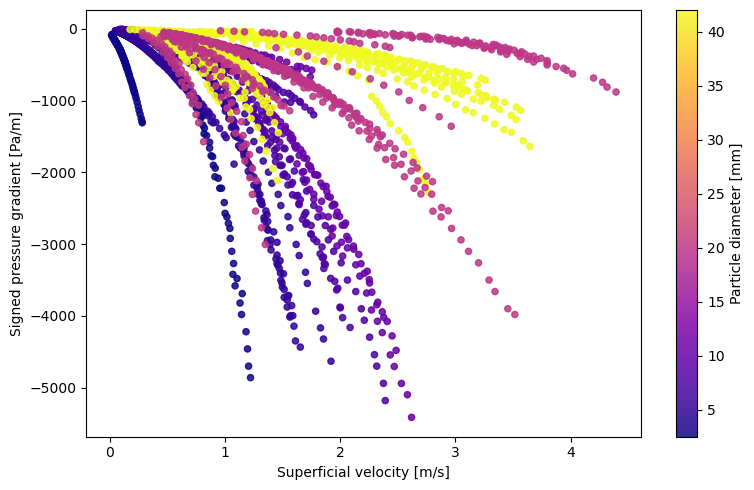

In [61]:
# relevant features:                                   analogous:
# average pressure gradient: delta P/L (Pa/m)          temperature gradient dT/dx (s)
# superficial velocity u_s (m/s)                       heat flux (q)
# particle size (mm)                                   material characteristics (m)

D["AVERAGE PRESSURE GRADIENT [Pa/m]"] = -1 * (D["PRESSURE DROP [Pa]"] / (D["COLUMN LENGTH [mm]"] / 1000))
Df = D[["AVERAGE PRESSURE GRADIENT [Pa/m]", "PARTICLES DIAMETER [mm]", "SUPERFICIAL VELOCITY [m/s]"]]

fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(
    Df["SUPERFICIAL VELOCITY [m/s]"],
    Df["AVERAGE PRESSURE GRADIENT [Pa/m]"],
    c=Df["PARTICLES DIAMETER [mm]"],
    cmap="plasma",
    s=20,
    alpha=0.85,
)

ax.set_xlabel("Superficial velocity [m/s]")
ax.set_ylabel("Signed pressure gradient [Pa/m]")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Particle diameter [mm]")

plt.tight_layout()
plt.show()

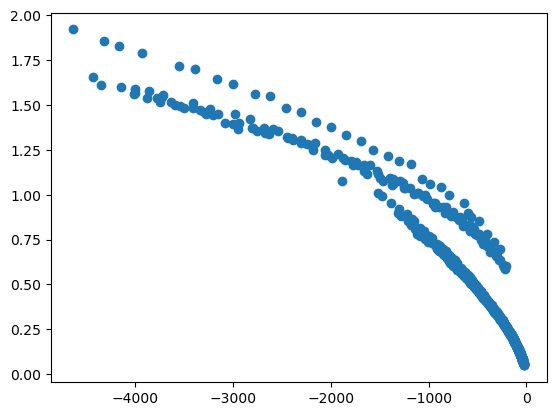

In [62]:
# filtered to particles around 5mm diameter
Dfs = Df[np.isclose(Df["PARTICLES DIAMETER [mm]"], 5, atol=0.5)]
plt.scatter(Dfs['AVERAGE PRESSURE GRADIENT [Pa/m]'], Dfs['SUPERFICIAL VELOCITY [m/s]'])
plt.show()

Training MSE: 0.006754782127784031


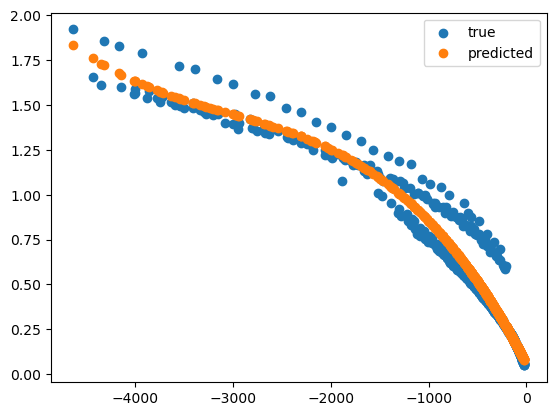

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error 

# fit and test polynomial regression
model = Pipeline(
    [
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('linear', LinearRegression())

    ]
)
X = Dfs['AVERAGE PRESSURE GRADIENT [Pa/m]'].to_numpy().reshape(-1, 1)
y = Dfs['SUPERFICIAL VELOCITY [m/s]'].to_numpy()
model.fit(X, y)
y_pred = model.predict(X)
train_mse = mean_squared_error(y, y_pred)
print(f"Training MSE: {train_mse}")

# plot results
plt.scatter(X, y, label='true')
plt.scatter(X, y_pred, label='predicted')
plt.legend()
plt.show()

# obtaining derivatives
lin = model.named_steps['linear']
c1, c2, c3 = lin.coef_
derivative = lambda x: c1 + 2*c2*x + 3*c3*x**2
derivatives = derivative(X)